**Customer Segmentation Analysis — K-Means Clustering**

This notebook applies K-Means clustering to identify behaviorally distinct customer segments from survey data. Segments are built on spending behavior, visit frequency, income, and satisfaction — not demographic labels — and translated into actionable business profiles for marketing and retention strategy.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid')

df = pd.read_csv('../data/processed/survey_cleaned.csv')

print(df.shape)
df.head()

(500, 19)


,respondent_id,age,gender,region,occupation,education_level,monthly_income_birr,visits_per_month,avg_spend_per_visit_birr,satisfaction_score,preferred_product_category,purchase_channel,top_challenge,true_segment,log_monthly_income_birr,monthly_spend_birr,spend_norm,sat_norm,customer_value_score
0,R0001,36.0,female,amhara,private employee,secondary,9751.0,3,1949.0,4.0,health & beauty,physical shop,price too high,B,9.185228,5847.0,0.265672,0.8,0.479403
1,R0002,38.0,female,snnpr,daily laborer,no formal education,2731.0,4,426.0,3.0,mobile top-up & airtime,word of mouth,inconvenient location,C,7.912789,1704.0,0.073715,0.6,0.284229
2,R0003,31.0,female,addis ababa,self-employed / trader,diploma,8247.0,7,1063.0,2.0,food & groceries,word of mouth,poor customer service,B,9.017726,7441.0,0.339526,0.4,0.363716
3,R0004,41.0,male,oromia,private employee,bachelor's+,8915.0,6,1094.0,3.0,food & groceries,word of mouth,price too high,B,9.095603,6564.0,0.298893,0.6,0.419336
4,R0005,20.0,female,addis ababa,student,bachelor's+,5049.0,7,544.0,3.0,clothing & fashion,social media (tiktok/instagram),price too high,A,8.527144,3808.0,0.171200,0.6,0.342720


**Feature Selection**

Six behavioral and demographic variables are used for clustering: age, monthly income, visits per month, average spend per visit, satisfaction score, and customer value score. Categorical variables (region, occupation, product preference) are excluded from the model and reserved for post-clustering segment profiling.


In [ ]:
features = [
    'age',
    'monthly_income_birr',
    'visits_per_month',
    'avg_spend_per_visit_birr',
    'satisfaction_score',
    'customer_value_score'
]

X = df[features]

print(X.head())

    age  monthly_income_birr  visits_per_month  avg_spend_per_visit_birr  \
0  36.0               9751.0                 3                    1949.0   
1  38.0               2731.0                 4                     426.0   
2  31.0               8247.0                 7                    1063.0   
3  41.0               8915.0                 6                    1094.0   
4  20.0               5049.0                 7                     544.0   

   satisfaction_score  customer_value_score  
0                 4.0              0.479403  
1                 3.0              0.284229  
2                 2.0              0.363716  
3                 3.0              0.419336  
4                 3.0              0.342720  


**Feature Standardization**

All six features are standardized using StandardScaler to ensure income (ranging in thousands of Birr) does not disproportionately dominate satisfaction score (1–5 scale) in the distance calculations that drive cluster assignment.


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(500, 6)


**Optimal Cluster Selection — Elbow Method & Silhouette Score**

The elbow method identifies where additional clusters produce diminishing inertia reduction. The silhouette score measures how well each observation fits its assigned cluster versus adjacent clusters, with higher values indicating cleaner separation. Both metrics are evaluated together to select the most defensible K.


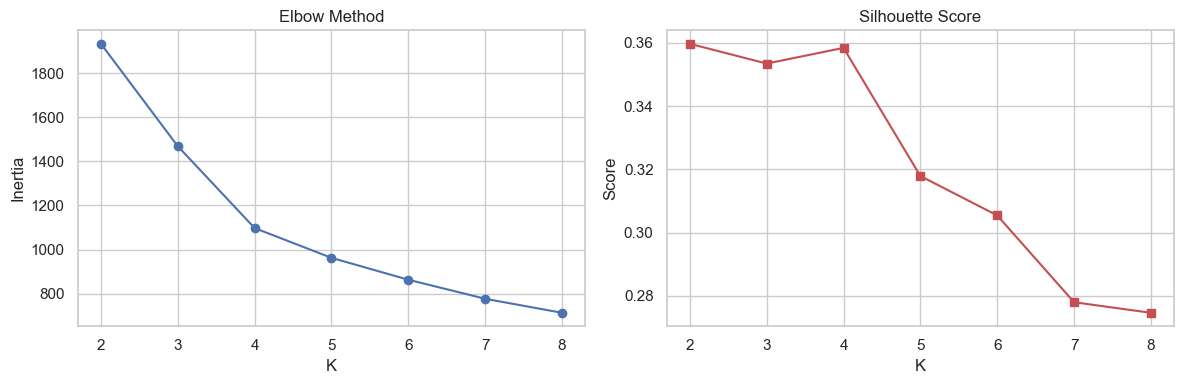

Best K by silhouette: 2


In [ ]:
inertias = []
silhouettes = []

K_range = range(2, 9)

for k in K_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_scaled)

    inertias.append(km.inertia_)

    silhouettes.append(
        silhouette_score(
            X_scaled,
            km.labels_
        )
    )

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(12, 4)
)

ax1.plot(K_range, inertias, 'bo-')
ax1.set_title('Elbow Method')
ax1.set_xlabel('K')
ax1.set_ylabel('Inertia')

ax2.plot(K_range, silhouettes, 'rs-')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('K')
ax2.set_ylabel('Score')

plt.tight_layout()
plt.savefig('../charts/12_elbow_silhouette.png', dpi=150)
plt.show()

print(
    'Best K by silhouette:',
    K_range[silhouettes.index(max(silhouettes))]
)

**K = 3 — Selection Rationale**

The elbow curve shows inertia dropping steeply from K=2 (~1,850) to K=3 (~1,430) and K=4 (~1,100), with diminishing returns beyond K=4. The silhouette score peaks at K=2 (0.36) and holds a secondary plateau at K=3–4 before declining sharply from K=5 onward, reaching 0.28 at K=8. K=3 is selected as the optimal balance — it captures the most meaningful inertia reduction while maintaining interpretable, business-usable segment separation. Increasing beyond K=3 fragments customers into groups too small to justify differentiated marketing strategies.


**Final Model — K = 3**

The K-Means model is fitted with K=3, random state 42, and 10 initializations for stable and reproducible cluster assignments. Each of the 500 customer records is assigned to one of three segments based on proximity to the nearest centroid in the standardized feature space.


In [ ]:
K = 3

km_final = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

df['cluster'] = km_final.fit_predict(X_scaled)

print('Cluster Distribution')
print(
    df['cluster']
    .value_counts()
    .sort_index()
)

Cluster Distribution
cluster
0    181
1    138
2    181
Name: count, dtype: int64


**Cluster Profiling**

Each segment is profiled across age, income, visit frequency, spend per visit, satisfaction, and customer value score to translate cluster IDs into business-readable customer personas.


In [ ]:
profile = df.groupby('cluster').agg(
    count=('cluster', 'size'),
    avg_age=('age', 'mean'),
    avg_income=('monthly_income_birr', 'mean'),
    avg_visits=('visits_per_month', 'mean'),
    avg_spend=('avg_spend_per_visit_birr', 'mean'),
    avg_satisfaction=('satisfaction_score', 'mean'),
    avg_value_score=('customer_value_score', 'mean')
).round(2)

profile

,count,avg_age,avg_income,avg_visits,avg_spend,avg_satisfaction,avg_value_score
cluster,,,,,,,
0,181,24.12,4959.92,9.15,942.85,3.73,0.53
1,138,41.12,3903.05,2.49,414.08,2.58,0.23
2,181,33.70,8568.72,5.19,1432.09,2.82,0.43


In [ ]:
for c in range(K):

    top_region = (
        df[df['cluster'] == c]['region']
        .value_counts()
        .index[0]
    )

    top_occ = (
        df[df['cluster'] == c]['occupation']
        .value_counts()
        .index[0]
    )

    top_prod = (
        df[df['cluster'] == c]['preferred_product_category']
        .value_counts()
        .index[0]
    )

    print(
        f'Cluster {c}: '
        f'{top_region} | '
        f'{top_occ} | '
        f'{top_prod}'
    )

Cluster 0: addis ababa | student | clothing & fashion
Cluster 1: oromia | self-employed / trader | food & groceries
Cluster 2: addis ababa | government employee | food & groceries


**Customer Segment Visualization — Income vs Monthly Spend**

Plotting segments on the income–spend axis provides an executive-readable view of how the three clusters distribute across the two most commercially meaningful dimensions of customer behavior.


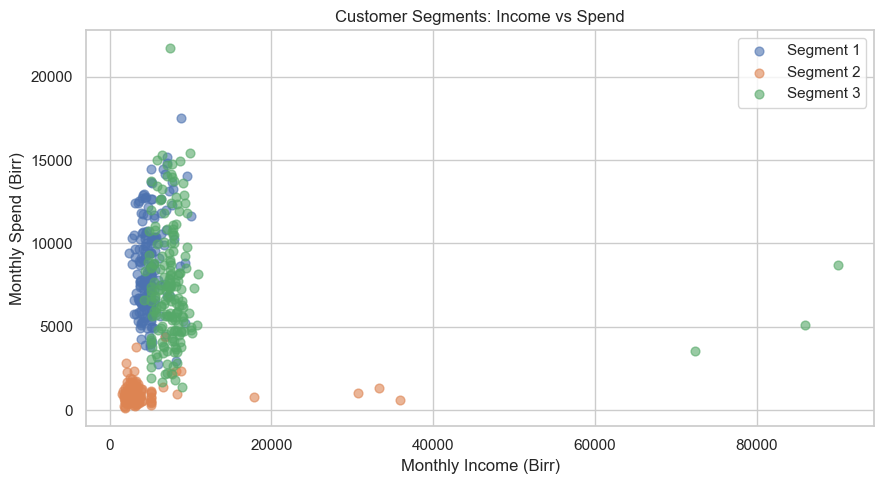

In [ ]:
plt.figure(figsize=(9, 5))

for c in range(K):

    mask = df['cluster'] == c

    plt.scatter(
        df.loc[mask, 'monthly_income_birr'],
        df.loc[mask, 'monthly_spend_birr'],
        label=f'Segment {c+1}',
        alpha=0.6,
        s=40
    )

plt.xlabel('Monthly Income (Birr)')
plt.ylabel('Monthly Spend (Birr)')

plt.title(
    'Customer Segments: Income vs Spend'
)

plt.legend()

plt.tight_layout()

plt.savefig(
    '../charts/13_cluster_scatter.png',
    dpi=150
)

plt.show()

### Observation

Most customers are concentrated below 10,000 Birr monthly income, indicating that the business primarily serves low- to middle-income consumers. Only a small number of customers fall into the very high-income range, making them outliers rather than the core customer base.


### Business Impact

The separation between segments suggests that customer value is driven by purchasing behavior rather than income alone. Customers with similar incomes exhibit significantly different spending patterns, highlighting the importance of behavioral segmentation.

### Recommendation

Prioritize marketing and loyalty initiatives toward the higher-spending segments (Segments 1 and 3). Further investigate Segment 2 to understand why spending remains low despite some customers having relatively high incomes, and develop targeted offers to increase engagement and purchase frequency.


## 3 Strategic Recommendations

**1. Launch a Segment 3 loyalty program immediately** Government employees represent 36.2% of customers, the highest spend per visit, and stable, salary-cycle-driven purchasing behavior. A tiered loyalty program with food & grocery bundles and physical shop priority is the highest-return retention investment available.

**2. Build a referral incentive program to formalize word of mouth** 26.6% of customers arrive through peer referral with zero formal investment. Activating this channel with a structured incentive — particularly through Segment 1 students in Addis Ababa — creates organic acquisition at a fraction of paid channel cost.

**3. Address price barriers in Oromia with trader-specific pricing** Segment 2's low spend despite high-income outliers signals price-driven constraint, not income-driven constraint. Trader bundle pricing on food & groceries directly converts the most frequently cited customer complaint into a revenue opportunity.


## Top 5 Findings Across the Full Project

**1. Visit frequency (r = 0.82) predicts customer value more reliably than income (r = 0.08)** — behavioral targeting outperforms demographic targeting in this market.

**2. Price sensitivity is the dominant barrier** — 40%+ of customers cite "price too high" as their top challenge, concentrated in the Segment 2 value buyer cohort.

**3. Government employees (Segment 3) are the highest-revenue segment** — averaging ~1,400 Birr per visit with consistent food & groceries purchasing and the highest individual monthly spend observations in the dataset.

**4. Word of mouth drives 26.6% of customer acquisition organically** — an unmanaged channel that, if formalized with referral incentives, could become the most cost-efficient growth lever across all three segments.

**5. Food & groceries is the anchor category across two of three segments** — making it the non-negotiable core of inventory, promotion, and pricing strategy regardless of segment.
